### imports and hyperparams

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

# added seed for reproduciblity
seed = 1
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

# sequence length
horizon = 200

n_burn  = 10
bs      = 256

# model size
out_dim = 1
units   = 32
n_epochs = 150
feats   = 1
tol     = 5
no_improve = 0


### load data

In [11]:
data  = np.load(
    "/home/michel/Documents/machineLearningForControl/code/gym-unbalanced-disk-5SC28-group-24/disc-benchmark-files/training-val-test-data.npz"
)
y_raw = data["th"]
u_raw = data["u"]


### make OE sequences

In [12]:

def make_sequences(u, y, nf):
    # each sample: u[k-nf:k], y[k-nf:k]
    U, Y = [], []
    for k in range(nf, len(u) + 1):
        U.append(u[k-nf:k])
        Y.append(y[k-nf:k])
    return np.array(U), np.array(Y)


### split and convert to tensors

In [13]:
# test set is the last 15%, no shuffle to keep time order
u_tv, u_test, y_tv, y_test = train_test_split(
    u_raw, y_raw, test_size=0.15, shuffle=False
)
u_train, u_val, y_train, y_val = train_test_split(
    u_tv, y_tv, test_size=0.40, shuffle=False
)

to_t = lambda seqs: [torch.tensor(s, dtype=torch.float32) for s in zip(*make_sequences(*seqs, nf=horizon))]

# build tensors
U_train_list, Y_train_list = make_sequences(u_train, y_train, horizon)
U_val, Y_val = make_sequences(u_val,   y_val,   horizon)
U_test, Y_test = make_sequences(u_test,  y_test,  horizon)

# shuffle training set
pairs = list(zip(U_train_list.tolist(), Y_train_list.tolist()))
random.shuffle(pairs)
u_shuf, y_shuf = zip(*pairs)

phi_train = torch.tensor(u_shuf, dtype=torch.float32)
t_train = torch.tensor(y_shuf, dtype=torch.float32)
phi_val = torch.tensor(U_val,  dtype=torch.float32)
t_val = torch.tensor(Y_val,  dtype=torch.float32)
phi_test = torch.tensor(U_test, dtype=torch.float32)
t_test = torch.tensor(Y_test, dtype=torch.float32)


### structure of RNN model

In [14]:
class RNN(nn.Module):
    def __init__(self, n_feats, n_out, n_hidden):
        super().__init__()
        self.n_hidden = n_hidden

        # reuse same block for both transitions
        block = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, n_hidden), nn.Tanh(),
            nn.Linear(n_hidden, n_hidden), nn.Tanh(),
            nn.Linear(n_hidden, n_out),
        ).float()

        self.h2h = block(n_hidden + n_feats, n_hidden) # hidden state update
        self.h2o = block(n_hidden + n_feats, n_out) # output at each step

    def forward(self, x):
        h = torch.zeros(x.shape[0], self.n_hidden, dtype=torch.float32, device=x.device)
        outs = []
        for i in range(x.shape[1]):
            u = x[:, i].unsqueeze(1)
            cat = torch.cat([h, u], dim=1)
            outs.append(self.h2o(cat))
            h = self.h2h(cat)
        return torch.stack(outs, dim=1).squeeze(2)

# check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model     = RNN(feats, out_dim, units).to(device)
optimizer = torch.optim.Adam(model.parameters())
loss_fn   = nn.MSELoss()

# move data to dervice
phi_train, t_train = phi_train.to(device), t_train.to(device)
phi_val, t_val = phi_val.to(device), t_val.to(device)
phi_test, t_test = phi_test.to(device), t_test.to(device)


### training loop

In [15]:
idx        = np.arange(len(phi_train), dtype=int)
best_val   = float("inf")
best_state = None
train_hist, val_hist = [], []

for epoch in range(n_epochs):
    model.train()
    np.random.shuffle(idx)

    for i in range(0, len(phi_train), bs):
        batch = idx[i:i+bs]
        pred = model(phi_train[batch])
        loss = loss_fn(pred[:, n_burn:], t_train[batch, n_burn:])  # skip burn-in
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # compute RMSE on full train and val after each epoch
    with torch.no_grad():
        model.eval()
        v_rmse = torch.mean((model(phi_val)[:, n_burn:] - t_val[:, n_burn:])   ** 2) ** 0.5
        t_rmse = torch.mean((model(phi_train)[:, n_burn:] - t_train[:, n_burn:]) ** 2) ** 0.5
        v_nrms = v_rmse / t_val[:, n_burn:].std() * 100

    print(f"epoch {epoch}  train {t_rmse:.4f}  val {v_rmse:.4f}  nrms {v_nrms:.2f}%")

    # save best model and check early stopping
    if v_rmse < best_val:
        best_val = v_rmse
        no_improve = 0
        best_state = model.state_dict()
    else:
        no_improve += 1

    if no_improve >= tol:
        print(f"early stop epoch {epoch}, best val {best_val:.4f}")
        break

    train_hist.append(t_rmse.item())
    val_hist.append(v_rmse.item())

# restore best weights
model.load_state_dict(best_state)

epoch 0  train 0.3833  val 0.3892  nrms 81.44%
epoch 1  train 0.2128  val 0.2275  nrms 47.61%
epoch 2  train 0.1862  val 0.2095  nrms 43.85%
epoch 3  train 0.1852  val 0.2079  nrms 43.51%
epoch 4  train 0.1780  val 0.2025  nrms 42.37%
epoch 5  train 0.1758  val 0.1992  nrms 41.68%
epoch 6  train 0.1780  val 0.2025  nrms 42.37%
epoch 7  train 0.1735  val 0.1978  nrms 41.38%
epoch 8  train 0.1744  val 0.1991  nrms 41.67%
epoch 9  train 0.1770  val 0.2005  nrms 41.97%
epoch 10  train 0.1733  val 0.1979  nrms 41.40%
epoch 11  train 0.1777  val 0.2026  nrms 42.40%
epoch 12  train 0.1758  val 0.2007  nrms 41.99%
early stop epoch 12, best val 0.1978


<All keys matched successfully>

### evaluate on test set

RMS:  0.232775 rad / 13.337051 deg
NRMS: 44.9023%


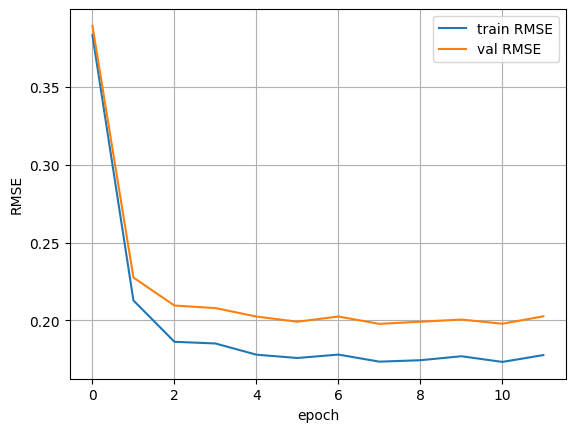

In [16]:
model.eval()
with torch.no_grad():
    test_rmse = torch.mean((model(phi_test)[:, n_burn:] - t_test[:, n_burn:]) ** 2) ** 0.5
    test_nrms = test_rmse / t_test[:, n_burn:].std() * 100

print(f"RMS:  {test_rmse:.6f} rad / {test_rmse/(2*np.pi)*360:.6f} deg")
print(f"NRMS: {test_nrms:.4f}%")

# plot learning curve
plt.plot(train_hist, label="train RMSE")
plt.plot(val_hist,   label="val RMSE")
plt.xlabel("epoch"); plt.ylabel("RMSE"); plt.legend(); plt.grid(); plt.show()

### 1-step prediction on full dataset

full RMS:  0.1654 rad / 9.4769 deg
full NRMS: 34.50%


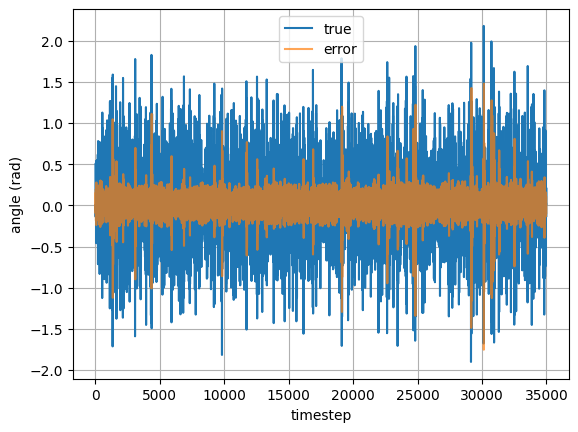

In [17]:
start, length = 1000, 150

x_full = torch.tensor(u_raw, dtype=torch.float32).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    y_pred_full = model(x_full).cpu().numpy().flatten()

rms = np.mean((y_pred_full[n_burn:] - y_raw[n_burn:]) ** 2) ** 0.5
print(f"full RMS:  {rms:.4f} rad / {rms/(2*np.pi)*360:.4f} deg")
print(f"full NRMS: {rms/np.std(y_raw[n_burn:])*100:.2f}%")

# plot error against true signal
plt.plot(y_raw, label="true")
plt.plot(y_pred_full - y_raw, label="error", alpha=0.7)
plt.xlabel("timestep"); plt.ylabel("angle (rad)"); plt.legend(); plt.grid(); plt.show()

### segment plot

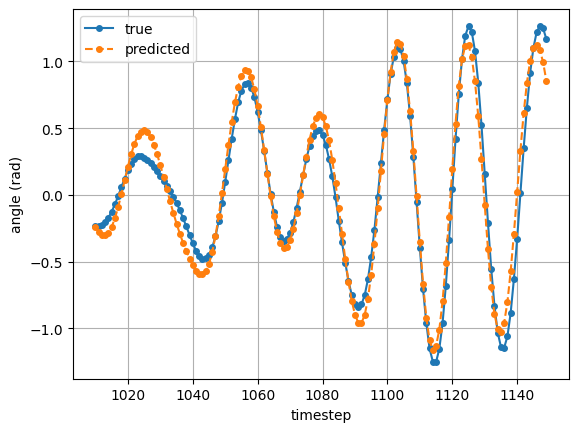

In [18]:
x_seg = torch.tensor(u_raw[start:start+length], dtype=torch.float32).unsqueeze(0).to(device)
with torch.no_grad():
    y_pred_seg = model(x_seg).cpu().numpy().flatten()

idx_plot = np.arange(start + n_burn, start + length)

plt.plot(idx_plot, y_raw[start+n_burn:start+length], marker="o", ms=4, label="true")
plt.plot(idx_plot, y_pred_seg[n_burn:], marker="o", ms=4, ls="--", label="predicted")
plt.xlabel("timestep"); plt.ylabel("angle (rad)"); plt.legend(); plt.grid(); plt.show()